QSI1D MRA layer

---

Kishore Kumar Tarafdar, 4Jul2025

In [1]:
pwd

'/data1/kishoretarafdar/src.port/multiresolution_kernels.v0/VolterraSys/nonlinear_kernels'

        Disable GPU: Force tensorflow to select CPU

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    

        Select a GPU with a memory limit

In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    '/data1/kishoretarafdar/src2D/GIIR/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id=1, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from TFDWT.DWT1DFB import DWT1D, IDWT1D
# from TFDWT.DWT2DFB import DWT2D, IDWT2D


2025-07-02 22:19:10.815211: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751474950.835581  214885 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751474950.841908  214885 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 22:19:10.863088: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


I0000 00:00:1751474953.085757  214885 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:23:00.0, compute capability: 8.6


In [4]:
import matplotlib.pyplot as plt

In [5]:
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
# x = tf.constant([1.,2], dtype=tf.float32)

In [4]:
# h = tf.constant([1,2], dtype=tf.float32)

        new QSI mra 1D layer
        export to py file

In [7]:
import tensorflow as tf
from TFDWT.DWT1DFB import DWT1D, IDWT1D
from TFDWT.DWT2DFB import DWT2D, IDWT2D

@tf.keras.utils.register_keras_serializable()
class QSIVolterra1D(tf.keras.layers.Layer): 
    """ Natural and MRA support
        VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>. 

    --@KKT@03Jul2025"""
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.filters = filters
        self.wave = wave
        if self.wave is not None: self.mra = True
        else: self.mra = False
        # self.dwt2 = DWT2D(self.wave, clean=False)
        # self.idwt1 = IDWT1D(self.wave, clean=False)

    def build(self, input_shape):
        self.N = input_shape[1]         # sequence length
        self.channels = input_shape[-1] # number of channels
        # Multi-channel kernel: (L, channels)
        kernel_shape = (self.L, self.channels, self.filters)
        self.h = self.add_weight(
            # shape=(self.L, self.channels),
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            name='UIR_kernel')
        super().build(input_shape)
    
    # def make_h2(self):
    #     # Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)
    #     h2 = tf.einsum('ico,jco->ijco', self.h, self.h)  # (L, L, channels)
    #     self.h2 = h2
    #     # Pad to (N, N, channels)
    #     paddings = [
    #         [0, self.N - self.L],
    #         [0, self.N - self.L],
    #         [0, 0],
    #         [0, 0]
    #     ]
    #     h2_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
    #     # self.h2_padded = h2_padded
    #     ## creating h[n-k1,n-k2]
    #     # N = Npoint
    #     n = tf.range(self.N)
    #     # Create circular indices for all possible shifts
    #     # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
    #     row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
    #     h2_rows_shifted = tf.gather(h2_padded, row_indices, axis=0)         # [N, N, N]
    #     h2_columns_shifted = tf.gather(h2_rows_shifted, row_indices,   # [N, N, N]
    #                                     axis=2, batch_dims=1)
    #     # self.h2_shifted = h2_columns_shifted
    #     # print('h2shifted', self.h2_shifted.shape)
    #     return h2_columns_shifted
    
    def make_mra_h2(self):
        # Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)
        h2 = tf.einsum('ico,jco->ijco', self.h, self.h)  # (L, L, channels)
        self.h2 = h2
        # Pad to (N, N, channels)
        paddings = [
            [0, self.N - self.L],
            [0, self.N - self.L],
            [0, 0],
            [0, 0]
        ]
        h2_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
        # self.h2_padded = h2_padded
        ## creating h[n-k1,n-k2]
        # N = Npoint
        n = tf.range(self.N)
        # Create circular indices for all possible shifts
        # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
        row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
        h2_rows_shifted = tf.gather(h2_padded, row_indices, axis=0)         # [N, N, N]
        h2_columns_shifted = tf.gather(h2_rows_shifted, row_indices,   # [N, N, N]
                                        axis=2, batch_dims=1)
        self.h2_shifted = h2_columns_shifted
        # print('h2shifted', self.h2_shifted.shape)

        def make_mra_kernel(h_shifted):
            shape = tf.shape(h_shifted)
            _ = tf.reshape(h_shifted, [shape[0], shape[1], shape[2], shape[3] * shape[4]])
            _ = DWT2D(self.wave, clean=False)(_)
            h_init = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4]])
            # print(h_init.shape, tf.squeeze(h_init))

            # dwt of third axis
            shape = tf.shape(h_init)
            shape
            _ = tf.reshape(h_init, [shape[0], shape[1], shape[2]*shape[3]*shape[4]])
            _ = tf.transpose(_, perm=[1,0,2])
            _ = DWT1D(self.wave, clean=False)(_)
            _ = tf.transpose(_, perm=[1,0,2])
            H = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4]])
            return H
        
        if self.mra == True:
            return make_mra_kernel(self.h2_shifted)
        else:
            return self.h2_shifted

        # ## update this for batched multichannel
        # _ = tf.expand_dims(tf.cast(h2_shifted, dtype=tf.float32), axis=-1)
        # h_init = DWT2D(self.wave, clean=False)(_)
        # print(tf.squeeze(h_init))

        # H = tf.expand_dims(
        #     tf.transpose(
        #         DWT1D(wave, clean=False)(tf.transpose(tf.squeeze(h_init, axis=-1), perm=[1,0,2])),
        #         perm=[1,0,2]),axis=-1)
        # H[:,:,:,0]

    def call(self, x):
        # self.x = x
        # x: (batch, N, channels)
        self.x2 = tf.einsum('bic,bjc->bijc', x, x)  # (batch, N, N, channels)
        print('x2', self.x2.shape)
        

        if self.mra==False:
            return self.__call_compute_in_natural_domain(self.x2)
        else:
            return self.__call_compute_with_mra_kernel(self.x2)
    
    def __call_compute_with_mra_kernel(self, x2):
        α2 = DWT2D(self.wave, clean=False)(x2)
        print('α2', α2.shape)
        H = self.make_mra_h2()
        ## Fitlering
        β = tf.einsum('ijkco,bjkc->bio', H, α2)
        print('β', β.shape)
        y2 = IDWT1D(self.wave, clean=False)(β)
        print('y2', y2.shape)
        return y2
    
    def __call_compute_in_natural_domain(self, x2):
        y2 = tf.einsum('ijkco, bjkc->bio', self.h2_shifted, x2)
        return y2

    def sanity_check(self):
        return self.__call_compute_with_mra_kernel(self.x2),  self.__call_compute_in_natural_domain(self.x2)  

    def get_filter(self):
        return self.h2

    def get_config(self):
        config = super().get_config()
        config.update({
            'kernel_size': self.L,
            'wavelet': self.wave,
            'filters': self.filters,
            'mra': self.mra
        })
        return config

        
if __name__ =='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"   
    ## Example
    # Functional model
    N, channels, filters = 8, 1, 1
    input_shape = (N, channels)  # Replace N with the actual size of x            #1D
    inputs = tf.keras.Input(shape=input_shape)
    H = QSIVolterra1D(filters=filters)
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    ## 1D Random data
    x = tf.random.normal((1, N, 1))
    y = tf.random.normal((1, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(x, y, epochs=5, verbose=1) 


x2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (None, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 8, 8, 1) +
α2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (8, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(8, 8, 8, 1) +
β (None, 8, 1)
y2 (None, 8, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra1d_2                │ (None, 8, 1)           │             4 │
│ (QSIVolterra1D)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
x2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (None, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 8, 8, 1) +
α2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (8, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(8, 8, 8, 1) +
β (None, 8, 1)
y2 (None, 8, 1)
x2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (None, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 8, 8, 1) +
α2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (8, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(8, 8, 8, 1) +
β (None, 8, 1)
y2 (None, 8, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 1.0408
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0379
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.0351
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.0323
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.0295


In [8]:
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
# x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
x.shape
# lay = LSVariantVolterra1Dmra(filters=1, Ny=21)
# y = lay(xx)
# y = lay(tf.concat([xx,xx], axis=-1))
# y.shape

_ = tf.expand_dims(tf.expand_dims(x,axis=-1),axis=0)
_.shape



TensorShape([1, 16, 1])

In [9]:
lay = QSIVolterra1D(filters=1, kernel_size=4, wave='haar')
y = lay(_)

x2 (1, 16, 16, 1)
(8, 16) (8, 16) H0, H1
(16, 16) (1, 16, 16, 1) <dtype: 'float32'> <dtype: 'float32'>
(1, 16, 16, 1) +
α2 (1, 16, 16, 1)
(8, 16) (8, 16) H0, H1
(16, 16) (16, 16, 16, 1) <dtype: 'float32'> <dtype: 'float32'>
(16, 16, 16, 1) +
β (1, 16, 1)
y2 (1, 16, 1)


(8, 16) (8, 16) H0, H1
(16, 16) (1, 16, 16, 1) <dtype: 'float32'> <dtype: 'float32'>
(1, 16, 16, 1) +
α2 (1, 16, 16, 1)
(8, 16) (8, 16) H0, H1
(16, 16) (16, 16, 16, 1) <dtype: 'float32'> <dtype: 'float32'>
(16, 16, 16, 1) +
β (1, 16, 1)
y2 (1, 16, 1)


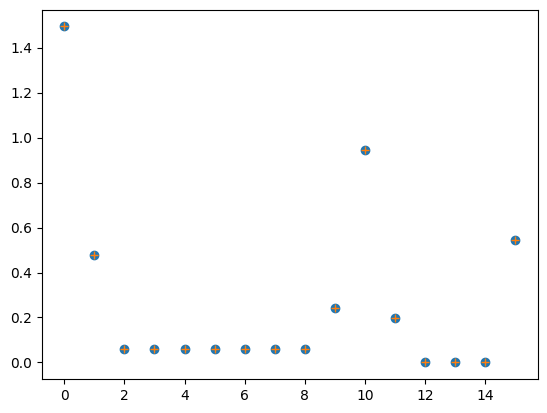

In [13]:
y, ynat = lay.sanity_check()
plt.plot(tf.squeeze(y).numpy(), 'o')
plt.plot(tf.squeeze(ynat).numpy(), '+')


In [100]:
ynat

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[0.40011325],
        [1.4177105 ],
        [1.0331836 ],
        [1.0331836 ],
        [1.0331836 ],
        [1.0331836 ],
        [1.0331836 ],
        [1.0331836 ],
        [1.0331836 ],
        [0.06013568],
        [0.14738789],
        [0.03035266],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.5947966 ]]], dtype=float32)>

In [101]:
y

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[0.40011322],
        [1.4177103 ],
        [1.0331835 ],
        [1.0331835 ],
        [1.0331835 ],
        [1.0331835 ],
        [1.0331835 ],
        [1.0331835 ],
        [1.0331833 ],
        [0.0601356 ],
        [0.14738786],
        [0.03035264],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.5947965 ]]], dtype=float32)>

In [61]:
## Example
# Generate a random multi-channel input
import numpy as np
np.random.seed(42)
batch_size, N, channels, filters = 1, N, 1, 1
x_np = np.random.randn(batch_size, N, channels).astype(np.float32)
x = tf.constant(x_np)
x.shape, x.dtype
# Instantiate the layer
# H = QSIVolterra1D(filters=filters)

# Call the layer
# ylay = H(x)

# print("Input shape:", x.shape)
# print("Output shape:", ylay.shape)
# print("Output (first batch example):\n", ylay[0].numpy())

(TensorShape([1, 8, 1]), tf.float32)

In [62]:
# ylay = H(tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0))
ylay = H(x)
ylay = tf.squeeze(ylay).numpy()
ylay

x2 (1, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (1, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(1, 8, 8, 1) +
α2 (1, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (8, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(8, 8, 8, 1) +
β (1, 8, 1)
y2 (1, 8, 1)


array([3.2833674 , 0.76369166, 0.15841484, 0.13677165, 1.8155693 ,
       1.2925385 , 0.03993465, 0.52839476], dtype=float32)

In [63]:
h2 = tf.squeeze(H.get_filter())
h2

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[ 9.8716365e-03,  5.3193588e-02,  8.4740996e-02, -2.0665557e-03],
       [ 5.3193588e-02,  2.8663513e-01,  4.5662925e-01, -1.1135693e-02],
       [ 8.4740996e-02,  4.5662925e-01,  7.2744143e-01, -1.7739914e-02],
       [-2.0665557e-03, -1.1135693e-02, -1.7739914e-02,  4.3261846e-04]],
      dtype=float32)>

In [64]:
x.shape

TensorShape([1, 8, 1])

In [10]:
# x = x[0,:,0]

In [65]:
x = tf.squeeze(x)

h_padded tf.Tensor(
[[ 9.8716365e-03  5.3193588e-02  8.4740996e-02 -2.0665557e-03
   0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [ 5.3193588e-02  2.8663513e-01  4.5662925e-01 -1.1135693e-02
   0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [ 8.4740996e-02  4.5662925e-01  7.2744143e-01 -1.7739914e-02
   0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [-2.0665557e-03 -1.1135693e-02 -1.7739914e-02  4.3261846e-04
   0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00  0.0000000e

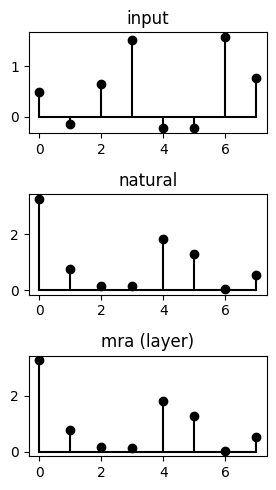

In [66]:


L = h2.shape[0] #filter length
# n = tf.range(L) 
Npoint = x.shape[0]
# Npoint = len(x)
paddings = [
        [0, Npoint - L],  # Depth dimension
        [0, Npoint - L]
        #    0,
        #    0,
        ]
# x
Npoint, paddings
h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
print('h_padded', h_padded)
h_padded.shape



x2 = tf.einsum('i,j->ij',x,x)
x2

### NAtural domain (alternative)
# q2 = tf.einsum('ijk,jk->i', h_columns_shifted, x2) ## faster
# slower version 
import numpy as np
def compute_q2(x2, h2):
    N = x2.shape[0]
    q2 = np.zeros(N).astype(float)
    for n in range(N):
        q2[n] = np.sum(h2 * x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)])
        print(x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)].shape)
    return q2

q2 = compute_q2(x2.numpy(),h_padded.numpy())
q2

plt.figure(figsize=(3,5))
plt.subplot(3,1,1), plt.stem(tf.squeeze(x).numpy(),'k', basefmt="k"), plt.title(f'input')
plt.subplot(3,1,2), plt.stem(tf.squeeze(q2).numpy(),'k', basefmt="k"), plt.title(f'natural')
# plt.subplot(3,1,3), plt.stem(tf.squeeze(y2).numpy(),'k', basefmt="k"), plt.title(f'Volterra (haar)')
plt.subplot(3,1,3), plt.stem(tf.squeeze(ylay).numpy(),'k', basefmt="k"), plt.title(f'mra (layer)')

plt.tight_layout()

In [13]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:

# h = tf.constant([1,2], dtype=tf.float32)

# # %% Quadratic kernel (m=2)
# #"""Quadratic kernel"""
# # x = [0,0,0,1,0,0,0,0]
# # filter init
# # h = tf.constant([1, 2, 1])
# h2 = tf.einsum('i,j->ij', h, h)
# print(h2)
# L = h.shape[0] #filter length
# # n = tf.range(L) 
# Npoint = x.shape[0]
# # Npoint = len(x)
# paddings = [
#         [0, Npoint - L],  # Depth dimension
#         [0, Npoint - L]
#         #    0,
#         #    0,
#         ]
# # x
# Npoint, paddings
# h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
# print('h_padded', h_padded)
# h_padded.shape

# ## creating h[n-k1,n-k2]
# N = Npoint
# n = tf.range(N)
# # Create circular indices for all possible shifts
# # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
# row_indices = tf.math.mod(n[:, tf.newaxis] - n, N)
# rows_shifted = tf.gather(h_padded, row_indices, axis=0)         # [N, N, N]
# rows_shifted
# h_columns_shifted = tf.gather(rows_shifted, row_indices,   # [N, N, N]
#                                 axis=2, batch_dims=1)
# h_columns_shifted, h_columns_shifted.shape




# _ = tf.expand_dims(tf.cast(h_columns_shifted, dtype=tf.float32), axis=-1)
# h_init = DWT2D(wave, clean=False)(_)
# print(tf.squeeze(h_init))

# H = tf.expand_dims(
#     tf.transpose(
#         DWT1D(wave, clean=False)(tf.transpose(tf.squeeze(h_init, axis=-1), perm=[1,0,2])),
#         perm=[1,0,2]),axis=-1)
# H[:,:,:,0]







# x2 = tf.einsum('i,j->ij',x,x)
# x2

# α2 = DWT2D(wave, clean=False)(tf.expand_dims(tf.expand_dims(x2, axis=-1),axis=0))
# α2.shape, tf.squeeze(α2)


# beta = tf.expand_dims(
#     tf.expand_dims(
#         tf.stack(
#             [tf.reduce_sum(H[k:k+1,:,:,:] * α2) for k in range(H.shape[0])]
#             ), axis=-1),axis=0)
# beta

# y2 = IDWT1D(wave, clean=False)(beta)
# y2



In [ ]:
# h = tf.constant([1,2], dtype=tf.float32)

# # %% Quadratic kernel (m=2)
# #"""Quadratic kernel"""
# # x = [0,0,0,1,0,0,0,0]
# # filter init
# # h = tf.constant([1, 2, 1])
# h2 = tf.einsum('i,j->ij', h, h)
# print(h2)

In [2]:
# import tensorflow as tf
# from TFDWT.DWT1DFB import DWT1D, IDWT1D
# from TFDWT.DWT2DFB import DWT2D, IDWT2D

# @tf.keras.utils.register_keras_serializable()
# class QSIVolterra1Dmra(tf.keras.layers.Layer):
#     def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
#         super().__init__(**kwargs)
#         self.L = kernel_size
#         self.filters = filters
#         self.wave = wave
#         self.dwt2 = DWT2D(self.wave, clean=False)
#         self.idwt1 = IDWT1D(self.wave, clean=False)

#     def build(self, input_shape):
#         self.N = input_shape[1]         # sequence length
#         self.channels = input_shape[-1] # number of channels
#         # Multi-channel kernel: (L, channels)
#         kernel_shape = (self.L, self.channels, self.filters)
#         h = self.add_weight(
#             # shape=(self.L, self.channels),
#             shape=kernel_shape,
#             initializer='glorot_uniform',
#             trainable=True,
#             name='UIR_kernel'
#         )
        
#         # Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)
#         h2 = tf.einsum('ico,jco->ijco', h, h)  # (L, L, channels)
#         self.h2 = h2
#         # Pad to (N, N, channels)
#         paddings = [
#             [0, self.N - self.L],
#             [0, self.N - self.L],
#             [0, 0],
#             [0, 0]
#         ]
#         h2_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
#         # self.h2_padded = h2_padded
#         ## creating h[n-k1,n-k2]
#         # N = Npoint
#         n = tf.range(self.N)
#         # Create circular indices for all possible shifts
#         # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
#         row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
#         h2_rows_shifted = tf.gather(h2_padded, row_indices, axis=0)         # [N, N, N]
#         h2_columns_shifted = tf.gather(h2_rows_shifted, row_indices,   # [N, N, N]
#                                         axis=2, batch_dims=1)
#         h2_shifted = h2_columns_shifted
#         # print('h2shifted', self.h2_shifted.shape)

#         def make_mra_kernel(h_shifted):
#             shape = tf.shape(h_shifted)
#             _ = tf.reshape(h_shifted, [shape[0], shape[1], shape[2], shape[3] * shape[4]])
#             _ = DWT2D(self.wave, clean=False)(_)
#             h_init = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4]])
#             # print(h_init.shape, tf.squeeze(h_init))

#             # dwt of third axis
#             shape = tf.shape(h_init)
#             shape
#             _ = tf.reshape(h_init, [shape[0], shape[1], shape[2]*shape[3]*shape[4]])
#             _ = tf.transpose(_, perm=[1,0,2])
#             _ = DWT1D(self.wave, clean=False)(_)
#             _ = tf.transpose(_, perm=[1,0,2])
#             H = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4]])
#             return H
#         self.H = make_mra_kernel(h2_shifted)
#         print('H',self.H.shape)
#         super().build(input_shape)

#         # ## update this for batched multichannel
#         # _ = tf.expand_dims(tf.cast(h2_shifted, dtype=tf.float32), axis=-1)
#         # h_init = DWT2D(self.wave, clean=False)(_)
#         # print(tf.squeeze(h_init))

#         # H = tf.expand_dims(
#         #     tf.transpose(
#         #         DWT1D(wave, clean=False)(tf.transpose(tf.squeeze(h_init, axis=-1), perm=[1,0,2])),
#         #         perm=[1,0,2]),axis=-1)
#         # H[:,:,:,0]

#     def call(self, x):
#         # x: (batch, N, channels)
#         x2 = tf.einsum('bic,bjc->bijc', x, x)  # (batch, N, N, channels)
#         print('x2', x2.shape)
#         α2 = self.dwt2(x2)
#         # α2 = DWT2D(self.wave, clean=False)(x2)
#         print('α2', α2.shape)
#         ## Fitlering
#         β = tf.einsum('ijkco,bjkc->bio', self.H, α2)
#         print('β', β.shape)

#         # print(x2.shape, self.h2_shifted.shape)
#         # y = tf.einsum('ijkco, bjkc->bio', self.h2_shifted, x2)
#         y2 = self.idwt1(β)
#         # y2 = IDWT1D(self.wave, clean=False)(β)
#         print('y2', y2.shape)
#         return y2
        
#     def get_filter(self):
#         return self.h2

#     def get_config(self):
#         config = super().get_config()
#         config.update({
#             'kernel_size': self.L,
#             'filters': self.filters,
#             'wavelet': self.wave
#         })
#         return config

        
# if __name__ =='__main__':
#     import os
#     os.environ["CUDA_VISIBLE_DEVICES"]="-1"   

#     # Define input shape and build the model for summary
#     N = 128
#     input_shape = (N, 1)  # Replace N with the actual size of x
#     inputs = tf.keras.Input(shape=input_shape)

#     # Create an instance of the custom layer
#     # h2 = np.array([[1, 2], 
#     #           [1, 3]]).astype(np.float32)
#     # H = TraceConv1Dio(kernel=tf.expand_dims(h2, axis=-1))
#     # (tf.expand_dims(tf.expand_dims(x2,axis=0),axis=-1))

#     #conv1d_filters=32, conv1d_kernel_size=3, 
#     #  conv2d_filters=32, conv2d_kernel_size=3)

#     # Apply the custom layer to the inputs
#     H = QSIVolterra1Dmra()
#     outputs = H(inputs)

#     # Build the model
#     model = tf.keras.Model(inputs=inputs, outputs=outputs)

#     # Print the model summary
#     model.summary()


In [3]:
# # Generate a random multi-channel input
# import numpy as np
# np.random.seed(42)
# batch_size, N, channels, filters = 1, N, 1, 1
# x_np = np.random.randn(batch_size, N, channels).astype(np.float32)
# x = tf.constant(x_np)
# x.shape, x.dtype
# # ylay = H(tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0))
# ylay = H(x)
# ylay = tf.squeeze(ylay).numpy()
# ylay
